In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import Image, display
import numpy as np
from jax import random
from matplotlib import rcParams  # type: ignore

from jaxcmr.fitting import ScipyDE as fitting_method
from jaxcmr.helpers import (
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
    format_floats,
)
from jaxcmr.likelihood import MemorySearchLikelihoodFnGenerator as loss_fn_generator
from jaxcmr import repetition
from jaxcmr.simulation import parameter_shifted_simulate_h5_from_h5, simulate_study_first_recall_and_free_recall
from jaxcmr.summarize import summarize_parameters

warnings.filterwarnings("ignore")

## Setup

In [ ]:
# Parameters

# Data parameters
base_data_tag = "CohenKahana2022"
data_tag = "CohenKahana2022_noELI"
data_path = "data/CohenKahana2022_noELI.h5"
trial_query = "data['session'] == 1"

# Run configuration
run_tag = "fixed_first_recall_best_of_3"
seed = 0
target_dir = "projects/CohenKahana2022"
experiment_count = 1

# Flow toggles
allow_repeated_recalls = False
filter_repeated_recalls = True
handle_elis = False
redo_fits = False
redo_sims = True
redo_figures = True

# Model configuration
model_name = "WeirdCMR"
model_factory_path = "jaxcmr.models_repfr.weird_cmr.BaseCMRFactory"

# Fitting hyperparameters
relative_tolerance = 0.01
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 1

# Parameter bounds
parameters = {
    "fixed": {},
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "stop_probability_scale": [2.220446049250313e-16, .9999999999999998],
        "stop_probability_growth": [2.220446049250313e-16, 9.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
    },
}


# Comparison analysis
comparison_analysis_paths = [
    "jaxcmr.analyses.spc.plot_spc",
    "jaxcmr.analyses.crp.plot_crp",
    "jaxcmr.analyses.pnr.plot_pnr",
]

# Parameter sweep
varied_parameter = 'stop_probability_growth'


In [3]:
# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product in ["fits", "figures", "simulations"]:
    product_dir = os.path.join(target_dir, product)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

max_size = np.max(data["pres_itemnos"])
connections = jnp.zeros((max_size, max_size))

comparison_analyses = [import_from_string(path) for path in comparison_analysis_paths]
model_factory = import_from_string(model_factory_path)

# derive list of query parameters from keys of `parameters`
parameters["fixed"]["allow_repeated_recalls"] = allow_repeated_recalls
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )

## Fitting

In [4]:
fit_path = os.path.join(product_dirs["fits"], f"{data_tag}_{model_name}_{run_tag}.json")
print(fit_path)

if os.path.exists(fit_path) and not redo_fits:
    with open(fit_path) as f:
        results = json.load(f)
        if "subject" not in results["fits"]:
            results["fits"]["subject"] = results["subject"]

else:
    base_params = parameters["fixed"]
    bounds = parameters["free"]
    fitter = fitting_method(
        data,
        connections,
        base_params,
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "bounds": bounds,
            "best_of": best_of,
        },
    )

    results = fitter.fit(trial_mask)
    results = dict(results)

    with open(fit_path, "w") as f:
        json.dump(results, f, indent=4)

results["data_query"] = trial_query
results["model"] = model_name
results["name"] = f"{data_tag}_{model_name}_{run_tag}"

with open(fit_path, "w") as f:
    json.dump(results, f, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)

projects/CohenKahana2022/fits/CohenKahana2022_noELI_WeirdCMR_fixed_first_recall_best_of_3.json
| | | CohenKahana2022 noELI WeirdCMR fixed first recall best of 3 |
|---|---|---|
| fitness | mean | 629.80 +/- 37.13 |
| | std | 183.29 |
| encoding drift rate | mean | 0.87 +/- 0.02 |
| | std | 0.09 |
| start drift rate | mean | 0.53 +/- 0.08 |
| | std | 0.37 |
| recall drift rate | mean | 0.93 +/- 0.01 |
| | std | 0.07 |
| shared support | mean | 20.78 +/- 3.91 |
| | std | 19.31 |
| item support | mean | 26.83 +/- 5.14 |
| | std | 25.38 |
| learning rate | mean | 0.32 +/- 0.04 |
| | std | 0.21 |
| primacy scale | mean | 12.69 +/- 4.82 |
| | std | 23.79 |
| primacy decay | mean | 33.78 +/- 6.23 |
| | std | 30.77 |
| stop probability scale | mean | 0.02 +/- 0.01 |
| | std | 0.02 |
| stop probability growth | mean | 0.31 +/- 0.02 |
| | std | 0.10 |
| choice sensitivity | mean | 56.72 +/- 6.40 |
| | std | 31.59 |



## Simulation

In [5]:
# Build params from fit and run a parameter sweep simulation
with open(fit_path) as f:
    results = json.load(f)
    if 'subject' not in results['fits']:
        results['fits']['subject'] = results['subject']

rng = random.PRNGKey(seed)
rng, rng_iter = random.split(rng)
trial_mask = generate_trial_mask(data, trial_query)
params = {key: jnp.array(val) for key, val in results['fits'].items()}  # type: ignore

# If parameter_values is empty, derive evenly spaced values from the bounds
min_value, max_value = parameters['free'][varied_parameter]
color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]
considered_values = jnp.linspace(
        start=min_value,
        stop=max_value,
        num=len(color_cycle)
    )[:-1].tolist()  # Remove the last value for consistency



sim = parameter_shifted_simulate_h5_from_h5(
    model_factory=model_factory,
    dataset=data,
    connections=connections,
    parameters=params,
    trial_mask=trial_mask,
    experiment_count=experiment_count,
    varied_parameter=varied_parameter,
    parameter_values=considered_values,
    rng=rng_iter,
    simulate_trial_fn=simulate_study_first_recall_and_free_recall,
)

In [6]:
jnp.max(params['stop_probability_scale'])

Array(0.19539778, dtype=float32)

In [7]:
# Optional: reset subjects for uniformity across datasets
for i in range(len(sim)):
    sim[i]["subject"] *= 0

    # Optionally filter repeated recalls in each simulated dataset
    if filter_repeated_recalls:
        sim[i]['recalls'] = repetition.filter_repeated_recalls(sim[i]['recalls'])

considered_values


[2.220446049250313e-16,
 0.011111111380159855,
 0.02222222276031971,
 0.03333333507180214,
 0.04444444552063942,
 0.0555555559694767,
 0.06666667014360428,
 0.07777778059244156,
 0.08888889104127884]

## Figures

![](projects/CohenKahana2022/figures/CohenKahana2022_noELI_WeirdCMR_fixed_first_recall_best_of_3_stop_probability_growth_shift_spc.png)


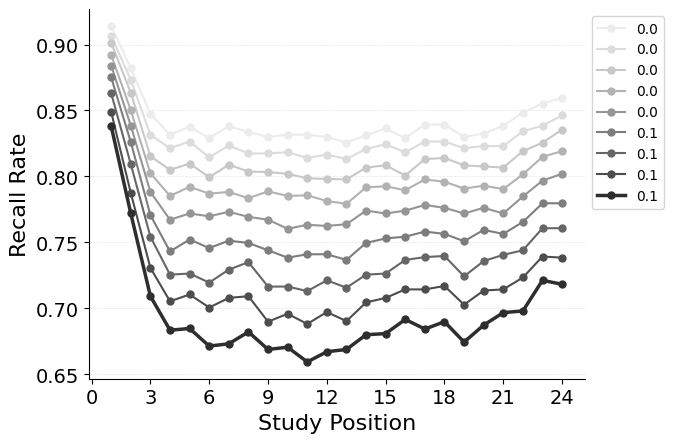

![](projects/CohenKahana2022/figures/CohenKahana2022_noELI_WeirdCMR_fixed_first_recall_best_of_3_stop_probability_growth_shift_crp.png)


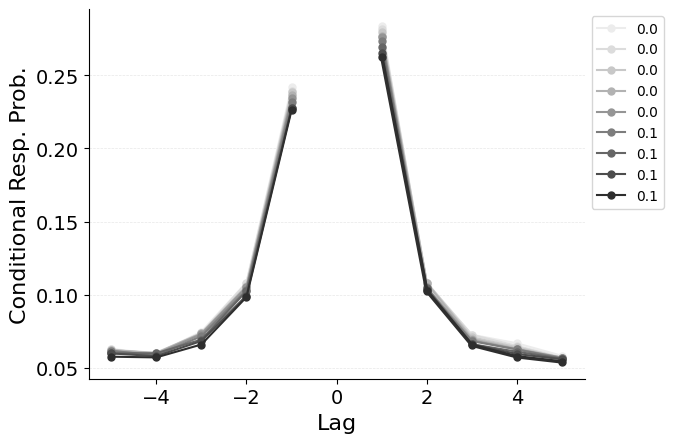

![](projects/CohenKahana2022/figures/CohenKahana2022_noELI_WeirdCMR_fixed_first_recall_best_of_3_stop_probability_growth_shift_pnr.png)


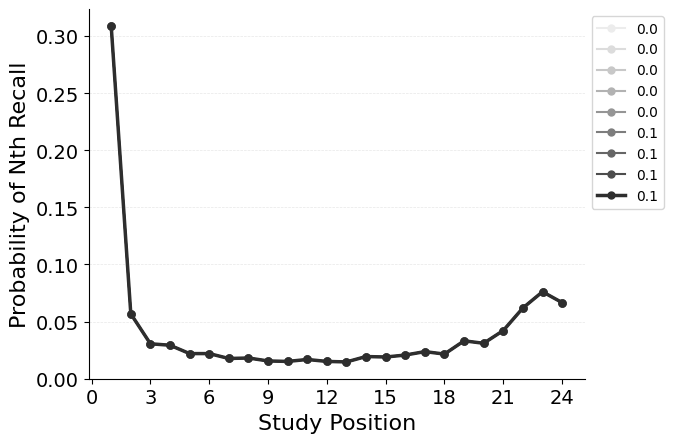

In [8]:
# | code-summary: parameter-shifted views

for analysis in comparison_analyses:
    figure_str = f"{data_tag}_{model_name}_{run_tag}_{varied_parameter}_shift_{analysis.__name__[5:]}.png"
    figure_path = os.path.join(product_dirs['figures'], figure_str)
    print(f"![]({figure_path})")

    if os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    # Create a color cycle using a continuous colormap
    cmap = plt.get_cmap("Greys")
    n_vals      = len(considered_values)
    eps         = 0.15             # how far to stay away from pure white
    color_cycle = [cmap(x) for x in np.linspace(eps, 1 - eps, n_vals)]
    color_cycle = [mcolors.rgb2hex(c) for c in color_cycle]
    
    # Use a common mask for simulated datasets
    sim_trial_mask = generate_trial_mask(sim[0], trial_query)

    axis = analysis(
        datasets=sim,
        trial_masks=[sim_trial_mask] * len(considered_values),
        color_cycle=color_cycle,
        distances=1 - connections,
        axis=plt.gca(),
        labels=format_floats(considered_values, 1),
        contrast_name=varied_parameter,
    )
    axis.get_lines()[-1].set_linewidth(2.5)   # thicken the lightest line

    # Format the plot (font sizes, legend location, etc.)
    axis.tick_params(labelsize=14)
    axis.set_xlabel(axis.get_xlabel(), fontsize=16)
    axis.set_ylabel(axis.get_ylabel(), fontsize=16)
    axis.legend(loc="upper left", bbox_to_anchor=(1, 1))

    plt.savefig(figure_path, bbox_inches='tight', dpi=600)
    plt.show()
